## Ứng dụng thuật toán K means ++ trong việc phân cụm khách hàng dựa trên mô hình RFM

### Tải các thư viện, công cụ

In [18]:
import pandas as pd

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

### Giai đoạn 0: Tiền xử lý dữ liệu

#### 0.1 Chuẩn hoá và xoá dữ liệu không hợp lệ

Thực hiện các nội dung sau:
1. Chuyển dữ liệu "UnitPrice" thành dạng float \
ví dụ: 2,31 -> 2.31
2. Định dạng datatime  
-> để máy đọc dữ liệu nhanh hơn
3. Xoá dữ liệu không hợp lệ (Quantity hoặc UnitPrice <=0) và dữ liệu trùng lặp

Lưu ý:
+ Xoá dữ liệu trùng lặp nghĩa là phải trùng cả mã đơn, mã kh, mã hàng thì mới xoá nên không bị mất dữ liệu.

In [19]:
# Khởi tạo và nạp dữ liệu
df_bang1 = pd.read_csv('Online Retail.csv', encoding='latin1') 

In [20]:
summary_table = pd.DataFrame({
    'Tên biến': df_bang1.columns,
    'Kiểu dữ liệu': df_bang1.dtypes.values,
    'Số giá trị null': df_bang1.isnull().sum().values,
    'Số giá trị phân biệt': df_bang1.nunique().values
})

summary_table

,Tên biến,Kiểu dữ liệu,Số giá trị null,Số giá trị phân biệt
0,InvoiceNo,object,0,25900
1,StockCode,object,0,4070
2,Description,object,1454,4223
3,Quantity,int64,0,722
4,InvoiceDate,object,0,23260
5,UnitPrice,object,0,1630
6,CustomerID,float64,135080,4372
7,Country,object,0,38


Nhận thấy các giá trị null xuất hiện ở 2 thuộc tính "Description" và "CustomerID". 

Ta bỏ qua xử lý null ở thuộc tính "Description" do không có giá trị thông tin. Đối với các dòng thiếu thuộc tính "CustomerID" -> loại bỏ.


In [21]:
# Thay đổi thuộc tính UnitPrice
df_bang1['UnitPrice'] = df_bang1['UnitPrice'].astype(str).str.replace(',', '.').astype(float)

# Định dạng datetime
df_bang1['InvoiceDate'] = pd.to_datetime(df_bang1['InvoiceDate'], format='%m/%d/%Y %H:%M') 


In [22]:
# Lọc dữ liệu 
df_bang1 = df_bang1.dropna(subset=['CustomerID'])
df_bang1 = df_bang1[df_bang1['Quantity'] > 0]
df_bang1 = df_bang1[df_bang1['UnitPrice'] > 0]
condition_c = df_bang1['InvoiceNo'].astype(str).str.contains('C', na=False)


# Giữ lại dữ liệu sạch
df_bang1 = df_bang1[~condition_c]

df_bang1 = df_bang1.drop_duplicates()
df_bang1.to_csv('bang1_clean.csv', index=False)

df_bang1

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


Kết quả: Từ 541,909 dữ liệu, sau khi làm sạch còn 392,692 dữ liệu.

In [23]:
summary_table = pd.DataFrame({
    'Tên biến': df_bang1.columns,
    'Kiểu dữ liệu': df_bang1.dtypes.values,
    'Số giá trị null': df_bang1.isnull().sum().values,
    'Số giá trị phân biệt': df_bang1.nunique().values
})

summary_table

,Tên biến,Kiểu dữ liệu,Số giá trị null,Số giá trị phân biệt
0,InvoiceNo,object,0,18532
1,StockCode,object,0,3665
2,Description,object,0,3877
3,Quantity,int64,0,301
4,InvoiceDate,datetime64[ns],0,17282
5,UnitPrice,float64,0,440
6,CustomerID,float64,0,4338
7,Country,object,0,37


In [24]:
stock_desc_count = (
    df_bang1.groupby('StockCode')['Description']
    .nunique()
    .reset_index(name='SoMoTa')
)

stock_desc_count[stock_desc_count['SoMoTa'] > 1]

,StockCode,SoMoTa
42,16156L,2
100,17107D,3
118,20622,2
170,20725,2
262,20914,2
...,...,...
3293,85184C,2
3294,85185B,2
3357,90014A,2
3358,90014B,2


In [25]:
desc_mode = (
    df_bang1.groupby('StockCode')['Description']
    .agg(lambda x: x.mode().iloc[0])
)

# Thay thế toàn bộ Description theo giá trị phổ biến nhất
df_bang1['Description'] = df_bang1['StockCode'].map(desc_mode)

In [26]:
summary_table = pd.DataFrame({
    'Tên biến': df_bang1.columns,
    'Kiểu dữ liệu': df_bang1.dtypes.values,
    'Số giá trị null': df_bang1.isnull().sum().values,
    'Số giá trị phân biệt': df_bang1.nunique().values
})

summary_table

,Tên biến,Kiểu dữ liệu,Số giá trị null,Số giá trị phân biệt
0,InvoiceNo,object,0,18532
1,StockCode,object,0,3665
2,Description,object,0,3647
3,Quantity,int64,0,301
4,InvoiceDate,datetime64[ns],0,17282
5,UnitPrice,float64,0,440
6,CustomerID,float64,0,4338
7,Country,object,0,37


#### 0.2 Xây dựng bảng 2

Thực hiện các nội dung sau:
1. Tạo cột Amount = Quantity*UnitPrice
2. Gộp tất cả thông tin vào 1 đơn hàng (TotalAmount, TotalQuantity...)

In [27]:
# Tạo cột Amount
df_bang1['Amount'] = df_bang1['Quantity'] * df_bang1['UnitPrice']

# groupby theo InvoiceNo
df_bang2 = df_bang1.groupby('InvoiceNo').agg(
    TotalAmount=('Amount', 'sum'),
    TotalQuantity=('Quantity', 'sum'),
    InvoiceDate=('InvoiceDate', 'first'),
    CustomerID=('CustomerID', 'first'),
    Country=('Country', 'first')
)

# Chuyển cột InvoiceNo thành cột bình thường, do khi thực hiện groupby thì InvoiceNo đã biến thành index
df_bang2 = df_bang2.reset_index()

# Xuất bảng 2
df_bang2.to_csv('bang2_invoice.csv', index=False)

df_bang2

,InvoiceNo,TotalAmount,TotalQuantity,InvoiceDate,CustomerID,Country
0,536365,139.12,40,2010-12-01 08:26:00,17850.0,United Kingdom
1,536366,22.20,12,2010-12-01 08:28:00,17850.0,United Kingdom
2,536367,278.73,83,2010-12-01 08:34:00,13047.0,United Kingdom
3,536368,70.05,15,2010-12-01 08:34:00,13047.0,United Kingdom
4,536369,17.85,3,2010-12-01 08:35:00,13047.0,United Kingdom
...,...,...,...,...,...,...
18527,581583,124.60,76,2011-12-09 12:23:00,13777.0,United Kingdom
18528,581584,140.64,120,2011-12-09 12:25:00,13777.0,United Kingdom
18529,581585,329.05,278,2011-12-09 12:31:00,15804.0,United Kingdom
18530,581586,339.20,66,2011-12-09 12:49:00,13113.0,United Kingdom


Kết quả: Ở bảng 2 chỉ còn 18,532 dữ liệu tương ứng với 18,532 đơn hàng khác nhau.

#### 0.3 Xây dựng bảng 3

In [28]:
# Định nghĩa mốc thời gian tính giá trị R 
snapshot_date = df_bang2['InvoiceDate'].max() + pd.Timedelta(days=1)

# groupby theo CustomerID
df_bang3 = df_bang2.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum'),
    Country=('Country', 'first')
)

# ép kiểu R thành int và xuất bảng 3
df_bang3['Recency'] = df_bang3['Recency'].astype(int)
df_bang3.to_csv('bang3_rfm.csv')

df_bang3

,Recency,Frequency,Monetary,Country
CustomerID,,,,
12346.0,326,1,77183.60,United Kingdom
12347.0,2,7,4310.00,Iceland
12348.0,75,4,1797.24,Finland
12349.0,19,1,1757.55,Italy
12350.0,310,1,334.40,Norway
...,...,...,...,...
18280.0,278,1,180.60,United Kingdom
18281.0,181,1,80.82,United Kingdom
18282.0,8,2,178.05,United Kingdom


Kết quả: Ở bảng 3 còn lại 4,338 dữ liệu tương ứng với 4,338 khách hàng khác nhau.

### Giai đoạn 1: Thống kê mô tả

#### 1.1 Phân tích cơ cấu địa lý và hình dáng dữ liệu gốc

Thực hiện các nội dung sau
1. Vẽ biểu đồ nhiệt hệ số tương quan
2. Vẽ biểu đồ cột với thuộc tính số lượng đơn hàng và quốc gia
3. Vẽ histogram cho 3 chỉ số R,F,M

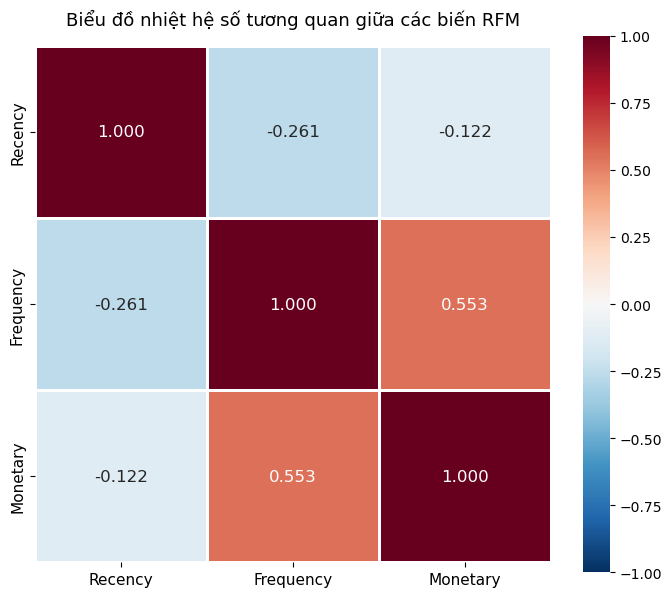

In [29]:
corr_matrix = df_bang3[['Recency', 'Frequency', 'Monetary']].corr()

plt.figure(figsize=(7, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=1,
    annot_kws={'size': 12}
)

plt.title(
    'Biểu đồ nhiệt hệ số tương quan giữa các biến RFM',
    fontsize=13,
    pad=15
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

Ba biến R, F, M không tương quan mạnh với nhau => có thể sử dụng để nghiên cứu hành vi khách hàng.

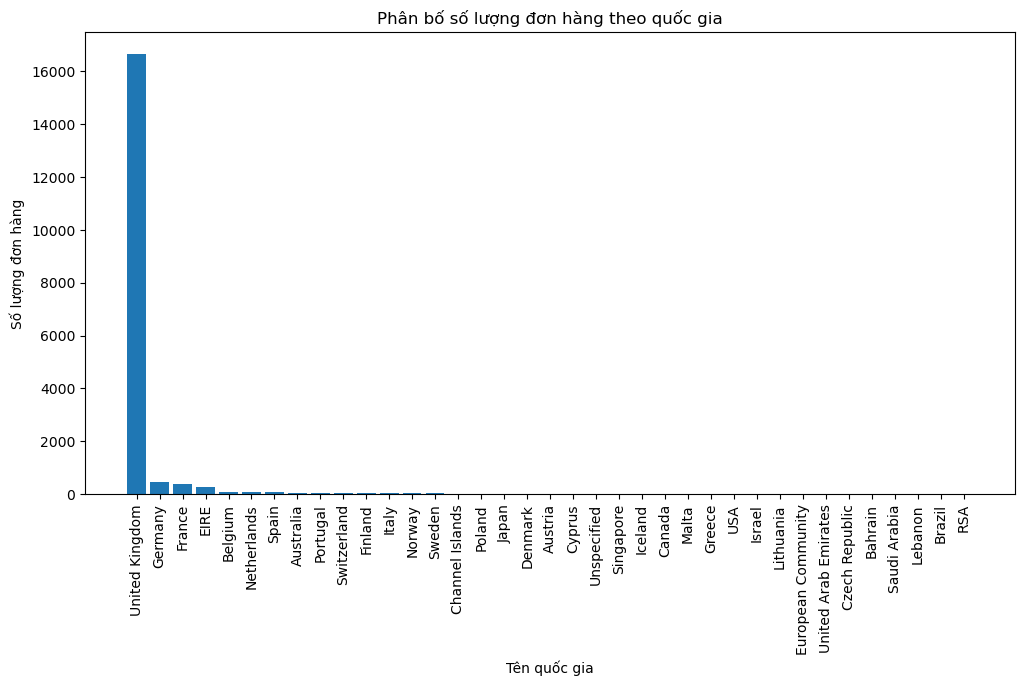

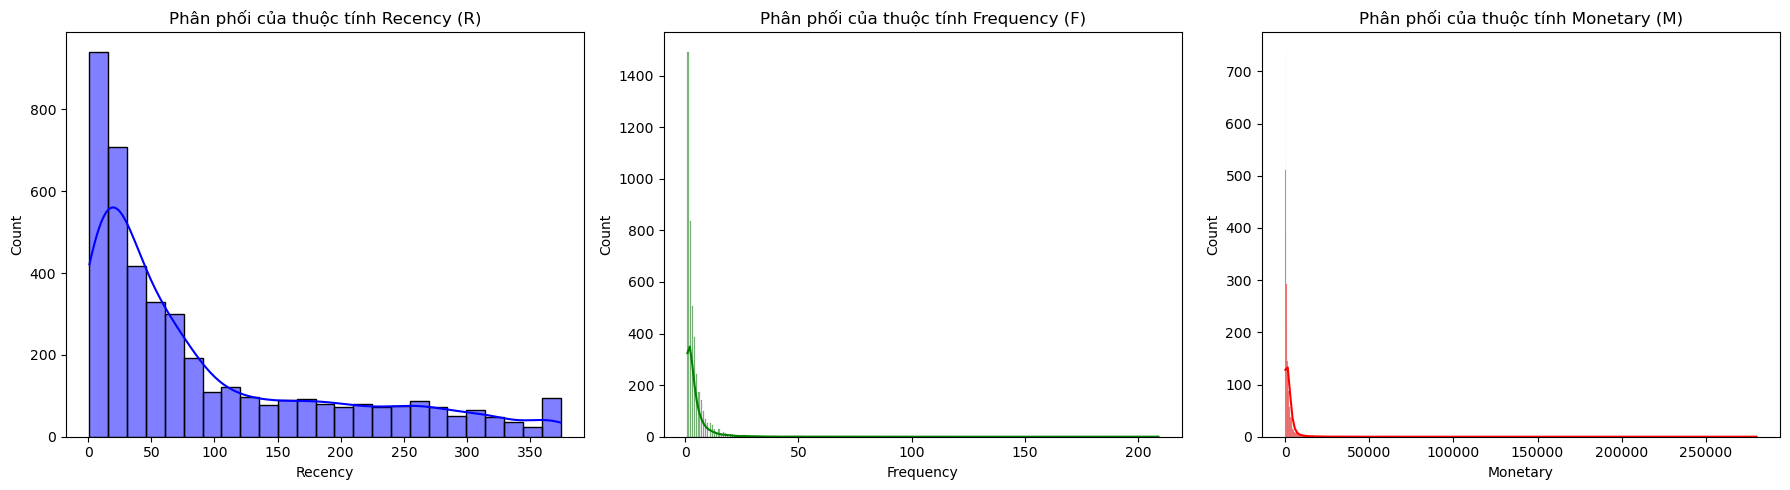

In [30]:
# Trực quan cơ cấu địa lý (từ bảng 2)
df_country = df_bang2['Country'].value_counts().reset_index()
df_country.columns = ['Country', 'Order_Count']


plt.figure(figsize=(12, 6))
plt.bar(
    df_country['Country'],
    df_country['Order_Count']
)
plt.title('Phân bố số lượng đơn hàng theo quốc gia')
plt.xlabel('Tên quốc gia')
plt.ylabel('Số lượng đơn hàng')
plt.xticks(rotation=90)


fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

# Vẽ Histogram cho Recency, Frequency, Monetary
sns.histplot(df_bang3['Recency'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Phân phối của thuộc tính Recency (R)')

sns.histplot(df_bang3['Frequency'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Phân phối của thuộc tính Frequency (F)')

sns.histplot(df_bang3['Monetary'], kde=True, ax=axes[2], color='red')
axes[2].set_title('Phân phối của thuộc tính Monetary (M)')

plt.tight_layout()
plt.show()

In [31]:
# Mô tả R,F,M
df_summary = df_bang3[['Recency', 'Frequency', 'Monetary']].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99])
print(df_summary)

           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2048.688081
std     100.014169     7.697998    8985.230220
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     306.482500
50%      51.000000     2.000000     668.570000
75%     142.000000     5.000000    1660.597500
90%     263.000000     9.000000    3640.841000
99%     369.000000    30.000000   19780.487800
max     374.000000   209.000000  280206.020000


Nhận xét:
- Dựa vào giá trị thống kê, từ phân vị 99% tới giá trị lớn nhất của F và M tồn tại 1 khoảng cách rất lớn. 
- Dựa vào Histogram, thấy rõ biểu đồ R lệch phải, biểu đồ của F và M lệch mạnh về bên phải.
- Từ hai điều trên, gợi ý cho ta rằng có một số điểm siêu ngoại lai, sẽ ảnh hưởng lớn tới mô hình. 

#### 1.2 Xử lý giá trị ngoại lai, vấn đề về độ lệch của Histogram

Thực hiện các nội dung:
1. Phương pháp Winsorization loại bỏ ảnh hưởng của outliner với thuật toán, xử lý các outliners sau. 
2. Chuẩn hoá dữ liệu

Lưu ý:
- Việc chuẩn hoá không làm thay đổi hình dáng đồ thị.

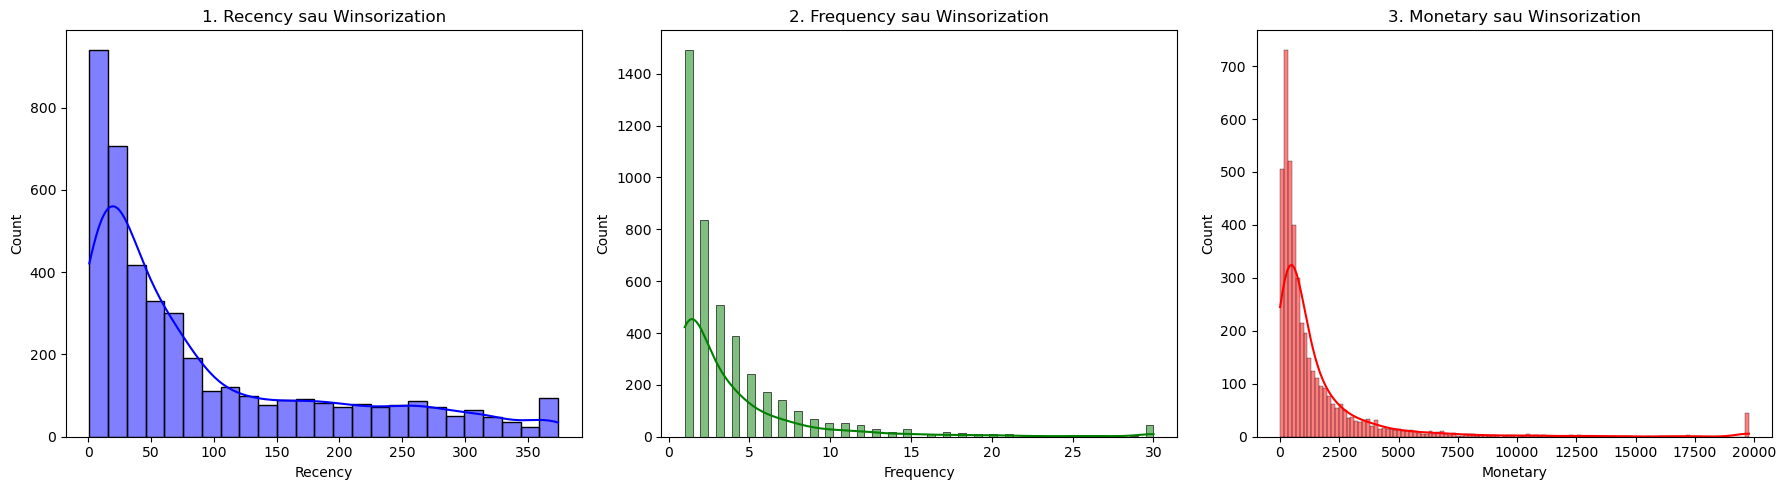

In [32]:
# Copy bảng 3
df_sub = df_bang3[['Recency', 'Frequency', 'Monetary']].copy()

# Phương pháp Winsorization tại phân vị 99%
q99_f = df_sub['Frequency'].quantile(0.99)
q99_m = df_sub['Monetary'].quantile(0.99)

# Thay thế các giá trị > q99 = q99 của F và M
df_sub['Frequency'] = np.where(df_sub['Frequency'] > q99_f, q99_f, df_sub['Frequency'])
df_sub['Monetary'] = np.where(df_sub['Monetary'] > q99_m, q99_m, df_sub['Monetary'])


fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

sns.histplot(df_sub['Recency'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('1. Recency sau Winsorization')

sns.histplot(df_sub['Frequency'], kde=True, ax=axes[1], color='green')
axes[1].set_title('2. Frequency sau Winsorization')

sns.histplot(df_sub['Monetary'], kde=True, ax=axes[2], color='red')
axes[2].set_title('3. Monetary sau Winsorization')

plt.tight_layout()
plt.show()



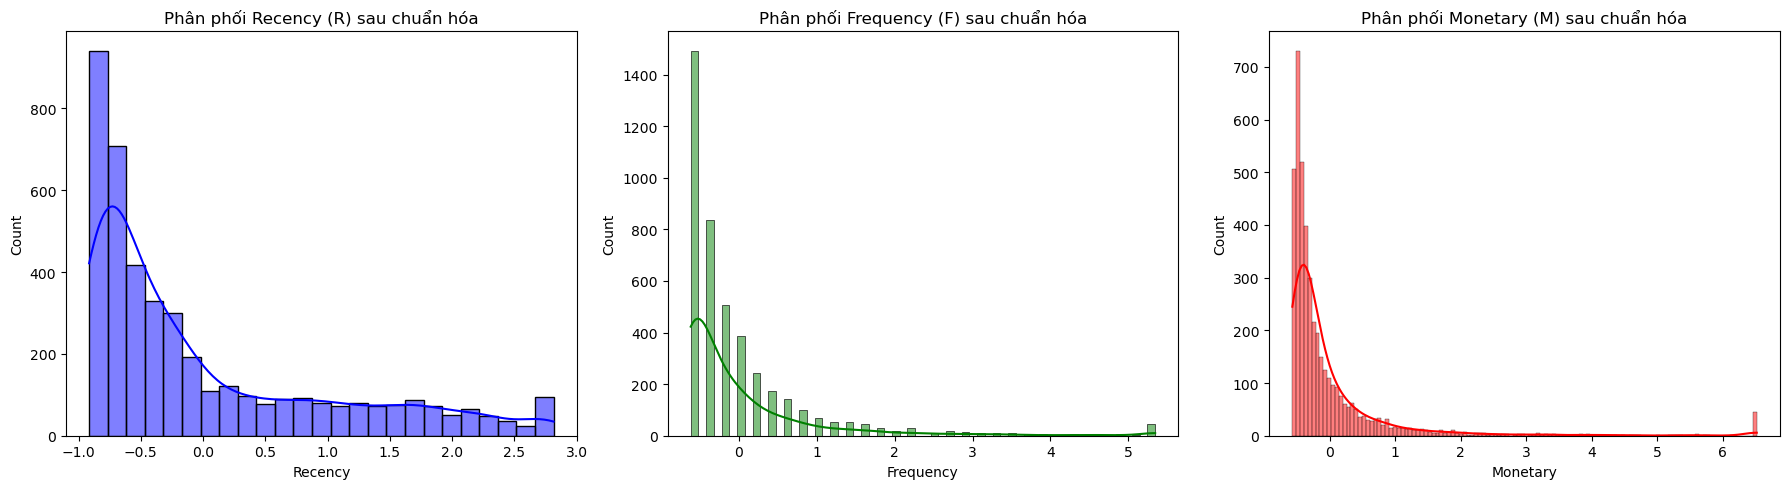

In [33]:
# Chuẩn hoá dữ liệu z = (x-mu)/sigma
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sub)

# Chuyển X_scaled thành dataframe để vẽ histogram
df_scaled = pd.DataFrame(
    X_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=df_sub.index
)

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

# Vẽ histogram sau chuẩn hoá
sns.histplot(df_scaled['Recency'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Phân phối Recency (R) sau chuẩn hóa')

sns.histplot(df_scaled['Frequency'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Phân phối Frequency (F) sau chuẩn hóa')

sns.histplot(df_scaled['Monetary'], kde=True, ax=axes[2], color='red')
axes[2].set_title('Phân phối Monetary (M) sau chuẩn hóa')

plt.tight_layout()
plt.show()

### Giai đoạn 2: Xây dựng thuật toán K-Means++

#### 2.1 Xác định số lượng cụm K tối ưu

Thực hiện các nội dung:
1. Thiết lập vòng lặp for với giá trị k từ 2 đến 10.
2. Với mỗi vòng lặp, tính tổng bình phương sai số (SSE) và điểm silhouette.
3. Vẽ đồ thị phương pháp khuỷu tay và phương pháp Silhouette.

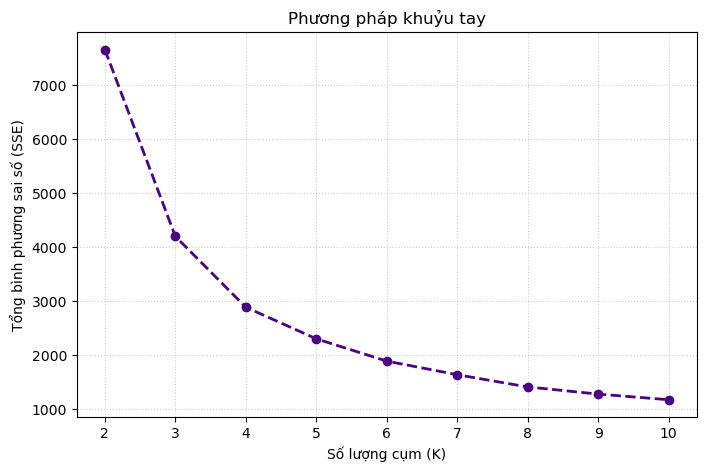

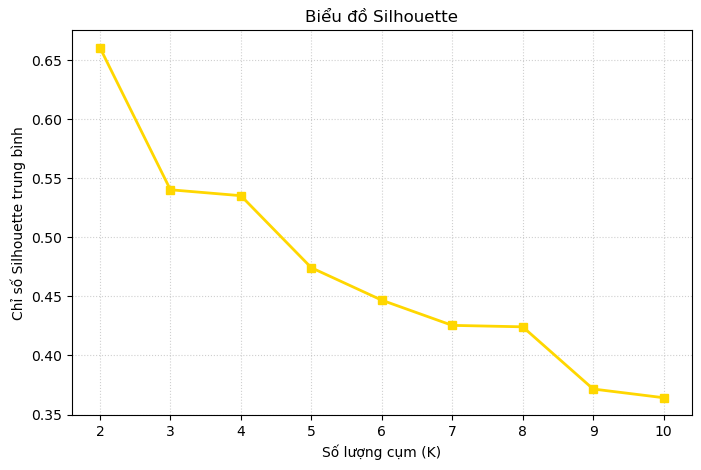

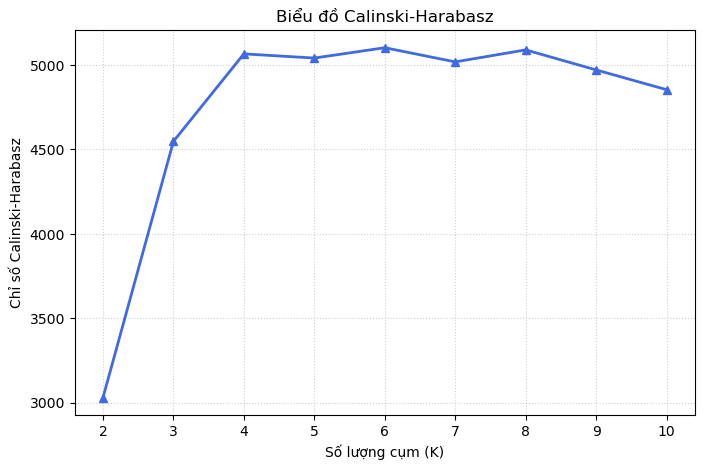

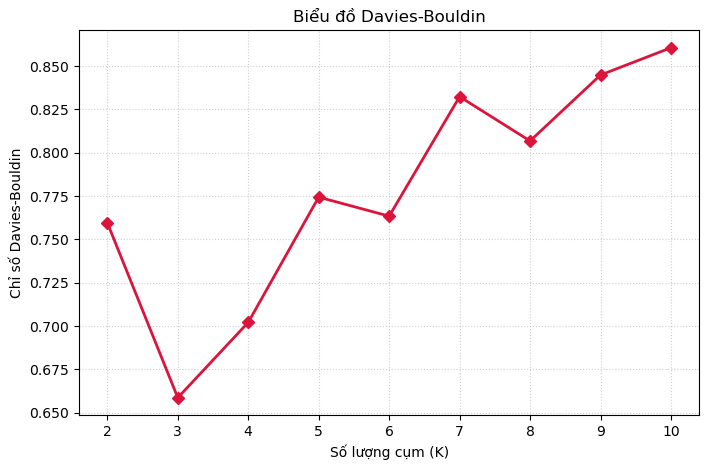

In [34]:
# Khởi tạo các danh sách lưu trữ kết quả 
sse = []
silhouette_scores = []
ch_values = []
dbi_values = []

k_range = range(2, 11)  # Khảo sát số cụm K chạy từ 2 đến 10 

for k in k_range:
    
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    # Điều kiện dừng là khoảng cách tâm cụm (mới - cũ) < 10^-4 hoặc tối đa 300 vòng lặp. 
    labels = kmeans.fit_predict(X_scaled)
    
    # 1. Ghi nhận giá trị SS
    sse.append(kmeans.inertia_)
    
    # 2. Ghi nhận điểm Silhouette trung bình
    
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)
    ch_values.append(calinski_harabasz_score(X_scaled, labels))
    dbi_values.append(davies_bouldin_score(X_scaled, labels))


# Biểu đồ 1: Phương pháp khuỷu tay (Elbow Method)
plt.figure(figsize=(8, 5))

plt.plot(k_range, sse,
         marker='o',
         linestyle='--',
         color='indigo',
         linewidth=2)

plt.title('Phương pháp khuỷu tay')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('Tổng bình phương sai số (SSE)')
plt.xticks(list(k_range))
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

# Biểu đồ 2: Hệ số Silhouette
plt.figure(figsize=(8, 5))

plt.plot(k_range, silhouette_scores,
         marker='s',
         linestyle='-',
         color='gold',
         linewidth=2)

plt.title('Biểu đồ Silhouette')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('Chỉ số Silhouette trung bình')
plt.xticks(list(k_range))
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

# Biểu đồ 3: Chỉ số Calinski-Harabasz
plt.figure(figsize=(8, 5))

plt.plot(
    k_range,
    ch_values,
    marker='^',
    linestyle='-',
    color='royalblue',
    linewidth=2
)

plt.title('Biểu đồ Calinski-Harabasz')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('Chỉ số Calinski-Harabasz')
plt.xticks(list(k_range))
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

# Biểu đồ 4: Chỉ số Davies-Bouldin
plt.figure(figsize=(8, 5))

plt.plot(
    k_range,
    dbi_values,
    marker='D',
    linestyle='-',
    color='crimson',
    linewidth=2
)

plt.title('Biểu đồ Davies-Bouldin')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('Chỉ số Davies-Bouldin')
plt.xticks(list(k_range))
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [35]:
evaluation_df = pd.DataFrame({
    'K': list(k_range),
    'SSE': sse,
    'Silhouette': silhouette_scores,
    'Calinski-Harabasz': ch_values,
    'Davies-Bouldin': dbi_values
})

evaluation_df

,K,SSE,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,2,7660.704456,0.660320,3029.994123,0.759526
1,3,4200.659289,0.540164,4547.635281,0.658558
2,4,2887.727876,0.535158,5065.956646,0.702059
3,5,2301.839257,0.474232,5041.179712,0.774382
4,6,1889.070024,0.446774,5102.360095,0.763383
5,7,1636.505765,0.425467,5018.496911,0.832374
6,8,1410.291386,0.424238,5089.531627,0.806806
7,9,1277.633253,0.371629,4970.843440,0.844886
8,10,1173.109702,0.364263,4853.911822,0.860634


Nhận xét:

Kết quả đánh giá cho thấy giá trị Silhouette cao nhất đạt được tại K = 2. Tuy nhiên, số cụm này còn khá tổng quát và chưa phản ánh đầy đủ sự đa dạng hành vi khách hàng trong mô hình RFM.

Khi tăng từ K = 3 lên K = 4, điểm Silhouette gần như không thay đổi đáng kể (0.540 và 0.535), trong khi SSE tiếp tục giảm mạnh từ 4201 xuống còn 2888. Điều này cho thấy việc tăng lên 4 cụm giúp cải thiện độ chặt của các cụm mà không làm suy giảm đáng kể chất lượng phân cụm.

Ngoài ra, sau K = 4, tốc độ giảm của SSE bắt đầu chậm lại rõ rệt và điểm Silhouette giảm tương đối nhiều. Do đó, ta lựa chọn K = 4 là số lượng cụm phù hợp nhằm cân bằng giữa chất lượng phân cụm và khả năng diễn giải hành vi khách hàng.


#### 2.2 Phân cụm với K = 4

Thực hiện nội dung:
1. Phân cụm bằng phương pháp K-means++ với K = 4.

In [36]:
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)

cluster_labels = kmeans.fit_predict(X_scaled)

df_rfm_final = df_bang3.copy()

# Nối trực tiếp mảng nhãn Cụm vào Bảng 3 
df_rfm_final['Cluster'] = cluster_labels

# Lưu trữ ma trận kết quả 
df_rfm_final.to_csv('kết quả phân cụm.csv', index=True)
print("\n=> Lưu tệp kết quả 'kết quả phân cụm.csv' thành công.")


=> Lưu tệp kết quả 'kết quả phân cụm.csv' thành công.


In [37]:
final_silhouette = silhouette_score(X_scaled, cluster_labels)
final_ch = calinski_harabasz_score(X_scaled, cluster_labels)
final_dbi = davies_bouldin_score(X_scaled, cluster_labels)

print(f"Điểm Silhouette: {final_silhouette:.3f}")
print(f"Chỉ số Calinski-Harabasz: {final_ch:.3f}")
print(f"Chỉ số Davies-Bouldin: {final_dbi:.3f}")
print(f"Tổng sai số bình phương - SSE: {kmeans.inertia_:.3f}")
print(f"Số vòng lặp hội tụ: {kmeans.n_iter_}")

Điểm Silhouette: 0.535
Chỉ số Calinski-Harabasz: 5065.957
Chỉ số Davies-Bouldin: 0.702
Tổng sai số bình phương - SSE: 2887.728
Số vòng lặp hội tụ: 11


### Giai đoạn 3: Trực quan hoá kết quả phân cụm

Thực hiện các nội dung:
1. Biểu đồ cơ cấu cụm
2. Biểu đồ phân cụm trong không gian 3D
3. Snake Plot

In [38]:
cluster_colors = {
    0: "#1f0a8a",
    1: "#b21ba5",
    2: "#f18f43",
    3: "#f0ea1a"
}

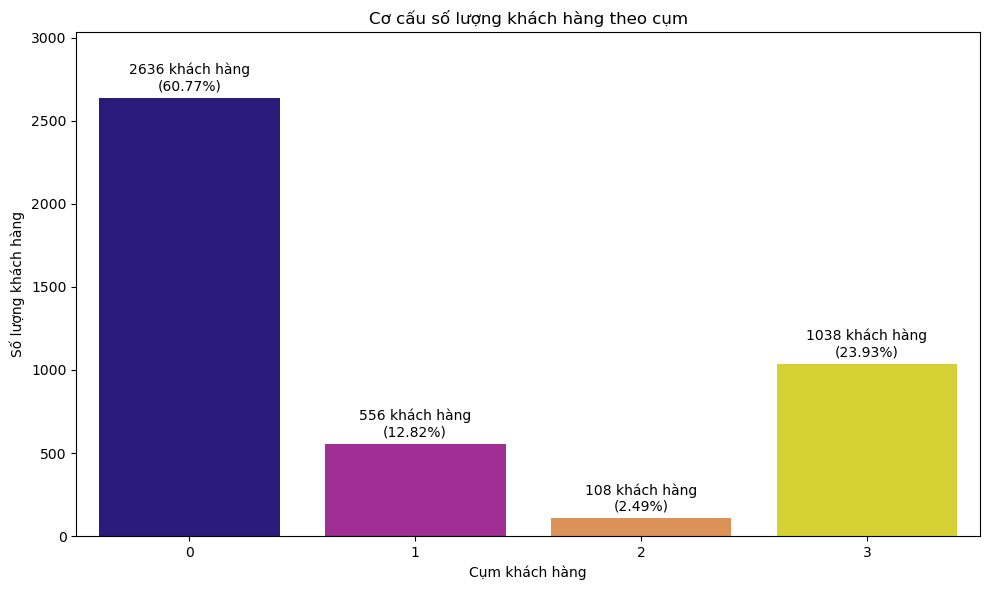

In [39]:
# Thống kê cơ cấu khách hàng theo cụm
cluster_counts = (
    df_rfm_final['Cluster']
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_counts.columns = ['Cụm', 'Số lượng']

cluster_counts['Tỷ lệ (%)'] = (
    cluster_counts['Số lượng']
    / cluster_counts['Số lượng'].sum()
    * 100
).round(2)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cluster_counts,
    x='Cụm',
    y='Số lượng',
    hue='Cụm',
    palette=cluster_colors,
    legend=False
)

plt.title('Cơ cấu số lượng khách hàng theo cụm')
plt.xlabel('Cụm khách hàng')
plt.ylabel('Số lượng khách hàng')

plt.ylim(
    0,
    cluster_counts['Số lượng'].max() * 1.15
)

for index, row in cluster_counts.iterrows():
    plt.text(
        index,
        row['Số lượng']
        + cluster_counts['Số lượng'].max() * 0.01,
        f"{int(row['Số lượng'])} khách hàng\n({row['Tỷ lệ (%)']}%)",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [40]:
cluster_profile = (
    df_rfm_final
    .groupby('Cluster')
    .agg({
        'Recency': ['count', 'mean', 'median'],
        'Frequency': ['mean', 'median'],
        'Monetary': ['mean', 'median']
    })
    .round(2)
)

cluster_profile

Recency                Frequency         Monetary          
          count    mean median      mean median      mean    median
Cluster                                                            
0          2636   48.25   38.0      2.78    2.0    919.00    676.40
1           556   21.89   12.0     10.70   10.0   4300.22   3739.23
2           108   18.06    4.0     34.19   26.0  33490.22  16590.72
3          1038  250.59  246.0      1.51    1.0    440.14    307.77

In [41]:
fig = px.scatter_3d(
    data_frame=df_rfm_final,
    x='Recency',
    y='Frequency',
    z='Monetary',
    color='Cluster',
    color_discrete_map=cluster_colors,
    title='Phân bố khách hàng trong không gian RFM theo cụm',
    labels={
        'Recency': 'Recency',
        'Frequency': 'Frequency',
        'Monetary': 'Monetary',
        'Cluster': 'Cụm'
    }
)

fig.update_layout(width=900, height=700)
fig.show()


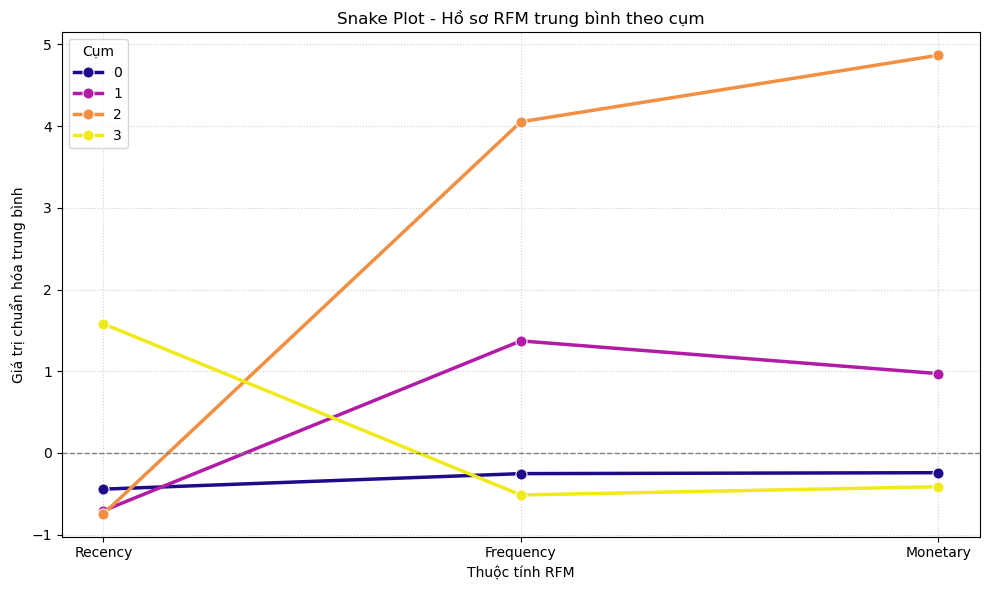

,Cluster,Recency,Frequency,Monetary
0,0,-0.442853,-0.252997,-0.241545
1,1,-0.706443,1.371825,0.971172
2,2,-0.744696,4.053819,4.867952
3,3,1.580509,-0.514111,-0.413293


In [42]:
# Tạo dataframe từ dữ liệu đã chuẩn hóa
df_snake = df_scaled.copy()

# Gắn nhãn cụm
df_snake['Cluster'] = cluster_labels

# Tính giá trị trung bình chuẩn hóa của từng cụm
snake_profile = (
    df_snake
    .groupby('Cluster')[['Recency', 'Frequency', 'Monetary']]
    .mean()
    .reset_index()
)

# Chuyển từ dạng rộng sang dạng dài để vẽ line plot
snake_melted = snake_profile.melt(
    id_vars='Cluster',
    value_vars=['Recency', 'Frequency', 'Monetary'],
    var_name='Thuộc tính RFM',
    value_name='Giá trị chuẩn hóa trung bình'
)

# Vẽ Snake Plot
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=snake_melted,
    x='Thuộc tính RFM',
    y='Giá trị chuẩn hóa trung bình',
    hue='Cluster',
    hue_order=[0, 1, 2, 3],
    palette=cluster_colors,
    marker='o',
    linewidth=2.5,
    markersize=8
)

plt.axhline(
    y=0,
    color='gray',
    linestyle='--',
    linewidth=1
)

plt.title('Snake Plot - Hồ sơ RFM trung bình theo cụm')
plt.xlabel('Thuộc tính RFM')
plt.ylabel('Giá trị chuẩn hóa trung bình')

plt.grid(True, linestyle=':', alpha=0.6)

plt.legend(
    title='Cụm',
    loc='best'
)

plt.tight_layout()
plt.show()

# Hiển thị bảng giá trị trung bình chuẩn hóa của các cụm
snake_profile

#### Violin Plot

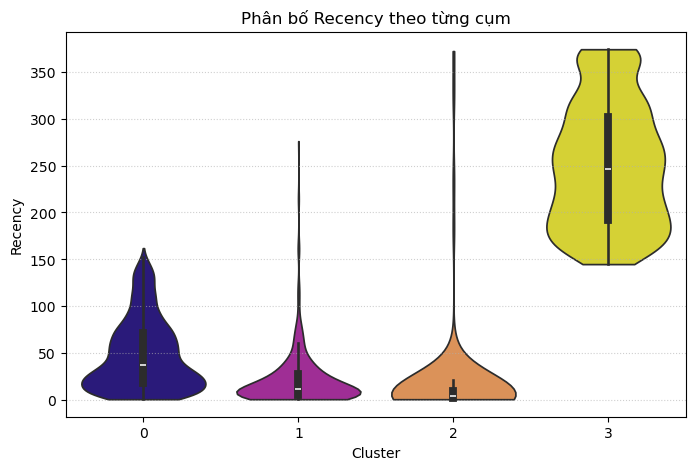

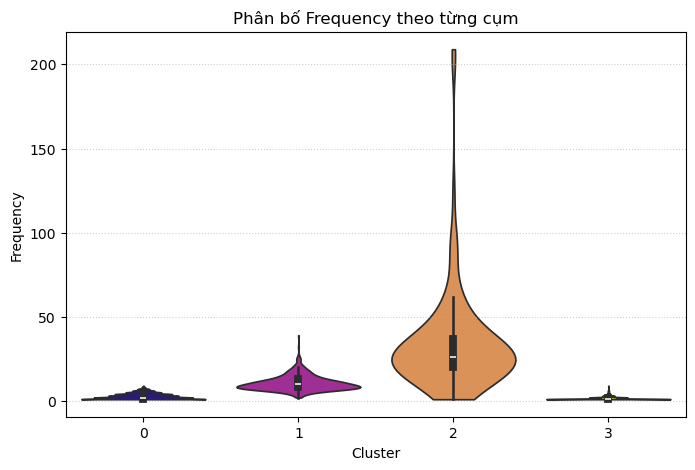

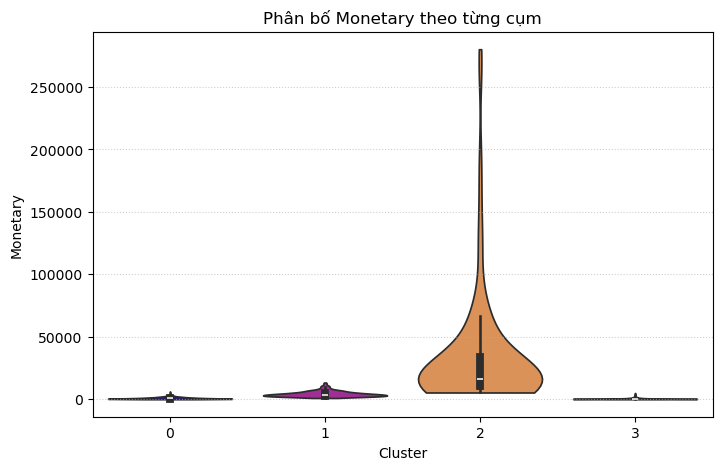

In [43]:
features = ['Recency', 'Frequency', 'Monetary']

for feature in features:
    plt.figure(figsize=(8,5))

    sns.violinplot(
        data=df_rfm_final,
        x='Cluster',
        y=feature,
        hue='Cluster',
        palette=cluster_colors,
        legend=False,
        inner='box',
        cut=0
    )

    plt.title(f'Phân bố {feature} theo từng cụm')
    plt.xlabel('Cluster')
    plt.ylabel(feature)

    plt.grid(axis='y', linestyle=':', alpha=0.6)

    plt.show()